# Hackathon 5: Income Predictor
**Who misses out on support? Predicting low income for targeted outreach (SDG 8)**

### How to run this notebook
- Put `adult.csv` in the same folder as this notebook. In Colab, upload it with the folder icon on the left.
- Choose **Runtime > Run all**. Everything runs from top to bottom, without extra installs.
- The whole notebook takes about 5 to 10 minutes in Colab. Most of this time is the tuning in step 6.
- The package versions we used are printed in the first code cell.

*This cell loads all the libraries we use, sets a fixed random seed and prints the package versions.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

RANDOM_STATE = 42

print("pandas", pd.__version__)
print("scikit-learn", sklearn.__version__)

pandas 2.2.3
scikit-learn 1.6.1


## Step 1: Framing the problem

### Target and positive class
We predict the column `income`: does a person earn more or less than $50,000 per year?
The **positive class is `<=50K`**: people with a low income. This is the group we want to reach.

### User and decision
Our user is a **social welfare organisation with a budget for 500 home visits per year**. The organisation has to decide which people to contact for income support, such as benefits or debt counselling. The model helps them use these 500 visits as well as possible.

### Which mistake is worse?
| Mistake | What happens | Consequence |
|---|---|---|
| **False negative** | A person with a low income is not contacted | They miss support they are entitled to |
| **False positive** | A person with a higher income is contacted | A home visit is lost that could have gone to someone else |

For the people involved, a **false negative is worse**. But the budget is limited, so a false positive also has a cost.

### Main metric: balanced accuracy
We chose **balanced accuracy** as our main metric before training any model. Our reasons:

**1. Our data is imbalanced.** 76% of the people have a low income and 24% have a higher income. If a metric does not correct for this, a model can score well by always picking the largest group.

**2. The other metrics do not work well here.** As a reference we use a *dummy*: a fake model that learns nothing and labels everyone as "low income".
- **Accuracy:** the dummy already scores 76% without learning anything.
- **Recall:** the dummy scores a perfect 1.0, because it never misses anyone. A real model can never beat this.
- **F1:** mainly looks at the positive class, so the dummy already scores 0.86. This makes it hard to see the difference with a real model.

**3. It fits our user.** The organisation wants two things:
- **find** people with a low income, because people who are missed do not get support;
- **skip** people with a higher income, because every unnecessary visit costs capacity.

Balanced accuracy measures both and gives them equal weight. It is the average of *"how many low incomes do we find?"* and *"how many higher incomes do we correctly skip?"*

**4. It makes the comparison with the baseline fair.** The dummy scores exactly 0.5, which is the same as guessing. Any score above 0.5 means the model has really learned something.

### Limitation of our choice
Balanced accuracy counts both mistakes **equally**, but we think a false negative is worse. Therefore:
- we also report **recall**, so we can see how many low-income people we miss;
- in step 9 we check if we should lower the decision threshold, so the model contacts more people.

*This cell saves our choices from step 1: the target column, the positive class and the main metric.*

In [ ]:
TARGET = "income"
POS_LABEL = "<=50K"
SCORING = "balanced_accuracy"

### What we did in step 1
- We chose what to predict: low income (`<=50K`) is the positive class.
- Our user is a social welfare organisation with a budget for 500 home visits per year.
- A missed person (false negative) is the worst mistake, but every unnecessary visit also costs capacity.
- Our main metric is balanced accuracy, because the data is imbalanced and the dummy then scores exactly 0.5.

## Step 2: Exploring the data
### 2A: Loading the data
**About the dataset:** we use the UCI Adult (Census Income) dataset, made by Barry Becker and Ronny Kohavi (1996) from the US Census of 1994. The original source is the UCI Machine Learning Repository (DOI [10.24432/C5XW20](https://doi.org/10.24432/C5XW20)). We downloaded the file from Hugging Face. On UCI the dataset has a CC BY 4.0 license. The file has 32,561 rows, which is the training part of the original dataset.

*This cell loads the dataset, tells pandas that `?` means a missing value and shows the first 5 rows.*

In [ ]:
df = pd.read_csv("adult.csv", na_values="?")

print("Number of rows and columns:", df.shape)
df.head()

Number of rows and columns: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 2B: Missing values

*This cell counts the missing values in every column.*

In [ ]:
df.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


### 2C: Class balance and duplicates

*This cell counts how many people have a low and a higher income, in numbers and in percentages.*

In [ ]:
print(df[TARGET].value_counts())
print()
print(df[TARGET].value_counts(normalize=True).round(3))

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


*This cell counts the rows that appear twice in the data.*

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 24


### 2D: Distributions and unusual values

*This cell shows a summary (mean, minimum, maximum and more) of the numeric columns.*

In [ ]:
NUMERIC = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]

df[NUMERIC].describe().round(1)

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.0,32561.0,32561.0,32561.0,32561.0,32561.0
mean,38.6,189778.4,10.1,1077.6,87.3,40.4
std,13.6,105550.0,2.6,7385.3,403.0,12.3
min,17.0,12285.0,1.0,0.0,0.0,1.0
25%,28.0,117827.0,9.0,0.0,0.0,40.0
50%,37.0,178356.0,10.0,0.0,0.0,40.0
75%,48.0,237051.0,12.0,0.0,0.0,45.0
max,90.0,1484705.0,16.0,99999.0,4356.0,99.0


*This cell draws a histogram for every numeric column, so we can see how the values are spread.*

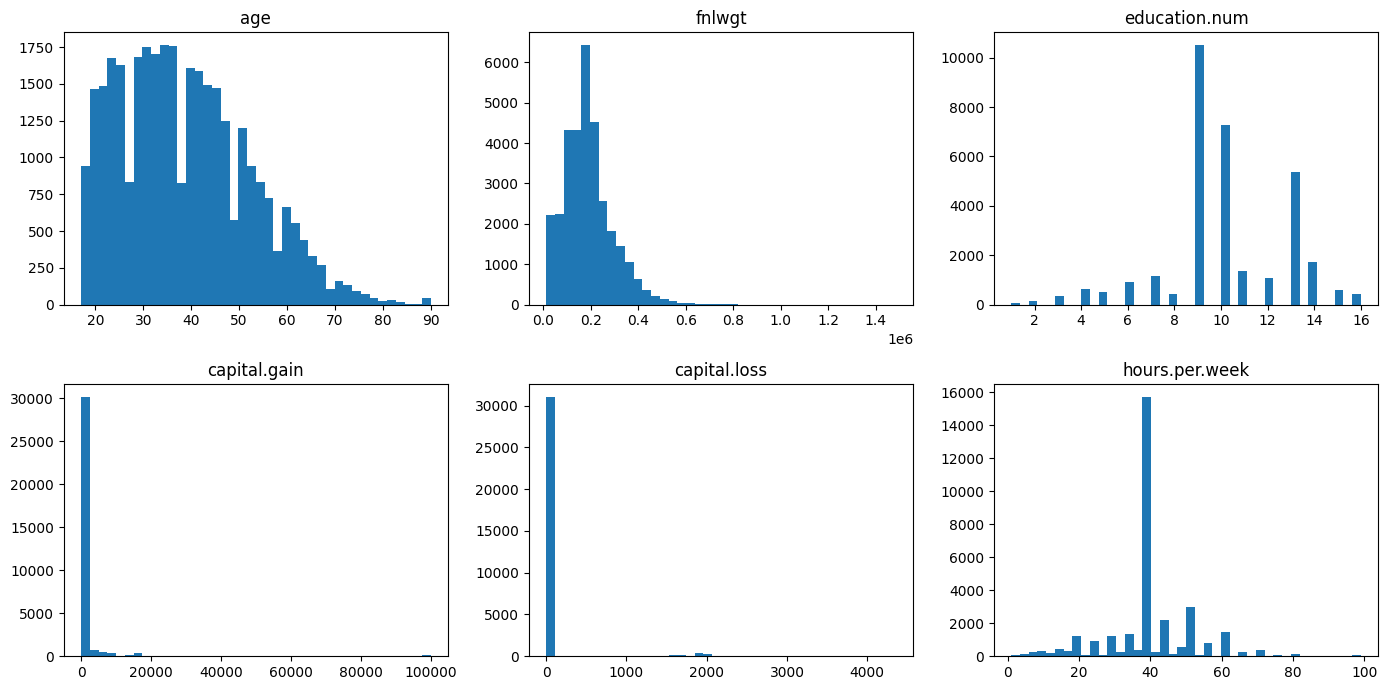

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, column in zip(axes.ravel(), NUMERIC):
    ax.hist(df[column], bins=40)
    ax.set_title(column)

plt.tight_layout()
plt.show()

*This cell counts the unusual values from the summary: the youngest age and the values at the maximum.*

In [ ]:
print("Youngest person:", df["age"].min())
print("Age exactly 90:", (df["age"] == 90).sum())
print("Exactly 99 hours per week:", (df["hours.per.week"] == 99).sum())
print("capital.gain exactly 99999:", (df["capital.gain"] == 99999).sum())
print("capital.gain is 0:", round((df["capital.gain"] == 0).mean() * 100, 1), "%")

Youngest person: 17
Age exactly 90: 43
Exactly 99 hours per week: 85
capital.gain exactly 99999: 159
capital.gain is 0: 91.7 %


### 2E: Investigating columns

*This cell compares `education` with `education.num`, to check if they contain the same information.*

In [ ]:
pd.crosstab(df["education"], df["education.num"])

education.num,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
education,,,,,,,,,,,,,,,,
10th,0,0,0,0,0,933,0,0,0,0,0,0,0,0,0,0
11th,0,0,0,0,0,0,1175,0,0,0,0,0,0,0,0,0
12th,0,0,0,0,0,0,0,433,0,0,0,0,0,0,0,0
1st-4th,0,168,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5th-6th,0,0,333,0,0,0,0,0,0,0,0,0,0,0,0,0
7th-8th,0,0,0,646,0,0,0,0,0,0,0,0,0,0,0,0
9th,0,0,0,0,514,0,0,0,0,0,0,0,0,0,0,0
Assoc-acdm,0,0,0,0,0,0,0,0,0,0,0,1067,0,0,0,0
Assoc-voc,0,0,0,0,0,0,0,0,0,0,1382,0,0,0,0,0


*This cell shows the share of low and higher incomes per sex and per race.*

In [ ]:
print("Share of low/high income per sex:")
print(pd.crosstab(df["sex"], df[TARGET], normalize="index").round(3))
print()
print("Share of low/high income per race:")
print(pd.crosstab(df["race"], df[TARGET], normalize="index").round(3))

Share of low/high income per sex:
income  <=50K   >50K
sex                 
Female  0.891  0.109
Male    0.694  0.306

Share of low/high income per race:
income              <=50K   >50K
race                            
Amer-Indian-Eskimo  0.884  0.116
Asian-Pac-Islander  0.734  0.266
Black               0.876  0.124
Other               0.908  0.092
White               0.744  0.256


*This cell checks if the `relationship` column gives away the sex of a person (a proxy).*

In [ ]:
pd.crosstab(df["relationship"], df["sex"])

sex,Female,Male
relationship,,
Husband,1,13192
Not-in-family,3875,4430
Other-relative,430,551
Own-child,2245,2823
Unmarried,2654,792
Wife,1566,2


### What we did in step 2
- We loaded 32,561 rows and found hidden missing values stored as `?`.
- The data is imbalanced (76% low income) and has 24 duplicate rows.
- Some values are capped (age 90, 99 hours per week, capital gain 99,999).
- We drop `education` and `fnlwgt`, keep `capital.gain` and `capital.loss`, and keep `sex` and `race` apart for the group check.

#### Details and results

**2B: Missing values**

**Hidden missing values:** in this file, missing values are stored as `"?"` instead of empty cells. Because of this, pandas first reported **0 missing values**. That is why we load the file with `na_values="?"`.

Now we can see that three columns have missing values:

| Column | Missing | % of 32,561 rows |
|---|---|---|
| `workclass` | 1,836 | 5.6% |
| `occupation` | 1,843 | 5.7% |
| `native.country` | 583 | 1.8% |

We do **not** remove these rows, because then we would lose almost 7% of the data. Instead, in step 4 we fill them with a separate category `"unknown"` inside the pipeline. The fact that a value is missing can also be useful information. `occupation` has 7 more missing values than `workclass`: these are people with `workclass = "Never-worked"`, who logically have no job.

**2C: Class balance and duplicates**

- **Class balance:** 75.9% of the people have a low income (`<=50K`) and 24.1% have a higher income (`>50K`). The data is imbalanced, which supports our choice of balanced accuracy (see step 1).
- **Duplicates:** there are 24 rows that appear twice. We remove them before the split, so the same row cannot end up in both the training set and the test set. Otherwise we would test the model on data it has already seen.

**2D: Distributions and unusual values**

- **No impossible ages:** the youngest person is 17, because the makers of the dataset only selected people older than 16.
- **Capped values:** many people have exactly the maximum value of a column. 43 people are exactly 90 years old, 85 people work exactly 99 hours per week and 159 people have a `capital.gain` of exactly 99,999. This means the data is probably **capped** (top-coded): "90" means "90 or older" and "99999" means "99,999 or more". These values are possible, so we keep them. But the real value can be higher, so we see this as a limitation.
- **Skewed distribution:** 91.7% of the people have a `capital.gain` of 0, so the few people with a high value are extreme outliers. This is one reason to scale the numbers in step 4.
- **Working hours:** `hours.per.week` has a clear peak at 40 hours, the standard working week.

**2E: Decisions on columns**

| Column | Decision | Reason |
|---|---|---|
| `education` | **Drop** | The crosstab shows that every education level belongs to exactly one value of `education.num` (for example Bachelors = 13). Both columns contain the same information. We keep `education.num` because it has a logical order. |
| `fnlwgt` | **Drop** | This is a weight calculated by the Census Bureau. It shows how many people in the US this row represents. It says nothing about the person, and our user would never know this value. |
| `capital.gain`, `capital.loss` | **Keep** | Income from investments is part of the total income, so these columns are close to the answer. We keep them because we assume the organisation has access to tax data, so this information is known before the decision is made. We mention this as a limitation. |
| `sex`, `race` | **Not used as features** | These are sensitive columns. 89% of women have a low income versus 69% of men, and 88% of Black people versus 74% of White people. If we used these columns, the model could treat people differently based on sex or race. We only keep them to check the model's mistakes per group in step 8. |

**Proxy warning:** removing `sex` does not make the model blind to sex. In the `relationship` column, "Husband" is almost always a man and "Wife" is almost always a woman. So `relationship` and `marital.status` still contain information about sex. We come back to this in the ethical reflection.

## Step 3: Splitting the data

*This cell removes the 24 duplicate rows.*

In [ ]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Removed duplicates:", len(df) - len(df_clean))
print("Rows left:", len(df_clean))

Removed duplicates: 24
Rows left: 32537


*This cell splits the data into the target `y`, the features `X` and the sensitive columns that we keep apart.*

In [ ]:
DROP_COLUMNS = ["fnlwgt", "education"]
SENSITIVE = ["sex", "race"]

y = (df_clean[TARGET] == POS_LABEL).astype(int)
groups = df_clean[SENSITIVE]
X = df_clean.drop(columns=[TARGET] + DROP_COLUMNS + SENSITIVE)

print("Features:", list(X.columns))
print("Share of positive class (low income):", round(y.mean(), 3))

Features: ['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']
Share of positive class (low income): 0.759


*This cell puts 20% of the data apart as a test set, with the same 76/24 ratio in both parts.*

In [ ]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "| share positive:", round(y_train.mean(), 3))
print("Test: ", X_test.shape, "| share positive:", round(y_test.mean(), 3))

Train: (26029, 10) | share positive: 0.759
Test:  (6508, 10) | share positive: 0.759


### What we did in step 3
- We removed the duplicates and split the data into 26,029 training rows and 6,508 test rows.
- The test set stays closed until step 7.

#### Details and results

- We removed the 24 duplicate rows **before** splitting. This step does not learn anything from the data, so it cannot leak information. It makes sure the same row cannot be in both the training set and the test set.
- We split the data into the target (`y`, where 1 = low income), the features (`X`) and the sensitive columns (`sex`, `race`). The sensitive columns are not used for training, but we keep them for the group check in step 8.
- We keep **20% apart as a test set**. We use `stratify=y`, so both sets have the same 76/24 ratio of low and higher incomes. A fixed `random_state` gives the same split every time.
- We use the test set **only once**, in step 7. All scaling, filling in of missing values and tuning is done on the training set only.

## Step 4: Pre-processing in a pipeline

*This cell lists which features are numbers and which features are categories (text).*

In [ ]:
NUMERIC_FEATURES = ["age", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
CATEGORICAL_FEATURES = ["workclass", "marital.status", "occupation", "relationship", "native.country"]

print(len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES), "features in total")

10 features in total


*This cell builds the pre-processing pipeline: fill in missing values, scale the numbers and one-hot encode the categories.*

In [ ]:
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
])

*This cell makes a small function that puts the pre-processing in front of any model.*

In [ ]:
def make_pipeline_with(model):
    return Pipeline([
        ("preprocess", preprocess),
        ("model", model),
    ])

*This cell tests the pre-processing on the training set and shows the number of columns before and after.*

In [ ]:
X_train_transformed = preprocess.fit_transform(X_train)
print("Before:", X_train.shape)
print("After: ", X_train_transformed.shape)

Before: (26029, 10)
After:  (26029, 84)


### What we did in step 4
- We built one pipeline that fills in missing values, scales the numbers and one-hot encodes the categories.
- The 10 features become 84 columns, and nothing leaks from the validation folds or the test set.

#### Details and results

- **Numeric features:** missing values are filled with the **median**. We use the median instead of the mean, because `capital.gain` has extreme values that pull the mean up. Then all values are **scaled** with `StandardScaler` to a mean of 0 and a standard deviation of 1.
- **Categorical features:** missing values become their own category `"unknown"`. Then every category becomes its own 0/1 column with **one-hot encoding**. `handle_unknown="ignore"` prevents an error when the test set contains a category that was not in the training set.
- We set `sparse_output=False`, so the encoder returns a normal (dense) table. With 84 columns this easily fits in memory, and it makes KNN about 3 times faster.
- **Why scaling matters:** KNN works with **distances**. Without scaling, a feature with large numbers (like `capital.gain`, up to 99,999) would count much more than a feature with small numbers (like `education.num`, 1 to 16). Logistic regression uses **regularisation**, which only treats all features fairly when they are on the same scale.
- **Why a pipeline:** the imputer and the scaler learn values from the data, such as the median and the mean. In a pipeline they only learn from the data the model is trained on. During cross-validation the pipeline is trained again on each training fold, so no information leaks from the validation fold or the test set.
- After pre-processing, the 10 original features become **84 columns**: 5 scaled numeric columns and 79 one-hot columns.

## Step 5: Baseline

*This cell creates the 5 stratified folds that all models will use.*

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

*This cell tests the dummy baseline with cross-validation.*

In [ ]:
dummy = DummyClassifier(strategy="most_frequent")

dummy_scores = cross_validate(
    dummy, X_train, y_train,
    cv=cv,
    scoring=SCORING,
    return_train_score=True,
)

print("Dummy balanced accuracy per fold:", dummy_scores["test_score"].round(3))
print(f"Dummy mean: {dummy_scores['test_score'].mean():.3f} ± {dummy_scores['test_score'].std():.3f}")

Dummy balanced accuracy per fold: [0.5 0.5 0.5 0.5 0.5]
Dummy mean: 0.500 ± 0.000


*This cell finds the best simple rule with one threshold on `education.num`, using the training set only.*

In [ ]:
best_threshold = None
best_score = 0

for threshold in sorted(X_train["education.num"].unique()):
    predictions = (X_train["education.num"] <= threshold).astype(int)
    score = balanced_accuracy_score(y_train, predictions)
    if score > best_score:
        best_score = score
        best_threshold = threshold

print("Best rule: education.num <=", best_threshold, "→ low income")
print(f"Balanced accuracy on training set: {best_score:.3f}")

Best rule: education.num <= 10 → low income
Balanced accuracy on training set: 0.669


### What we did in step 5
- The dummy scores 0.500 and the best simple rule (`education.num <= 10`) scores 0.669.
- These are the scores our models have to beat.

#### Details and results

- We made **5 stratified folds** with a fixed `random_state`. All models are tested on these same folds, so the comparison is fair.
- **Dummy baseline:** a `DummyClassifier` that always predicts the most common class (low income). It scores exactly **0.5** balanced accuracy, which is the same as guessing. Every model has to beat this.
- **Simple rule:** "predict low income if `education.num` ≤ t". We chose the threshold t on the training set only. This rule does not need machine learning. If our models do not clearly beat it, ML is not worth the extra effort.
- **Results:** the dummy scores 0.500 ± 0.000 on every fold. The best simple rule is `education.num ≤ 10`, with a score of 0.669 on the training set. Our ML models have to clearly beat this score.

## Step 6: Tuning with cross-validation
Every model has settings that we have to choose before training: the **hyperparameters**. We use `GridSearchCV` to try different values. For every value, it runs a 5-fold cross-validation on the training set. All models use the same folds and the same metric (balanced accuracy). At the end, `GridSearchCV` trains the model with the best setting again on the full training set. The test set is not used in this step.

### 6A: KNN

*This cell tunes KNN: it tries 8 values for `n_neighbors` with 5-fold cross-validation.*

In [ ]:
knn_grid = {"model__n_neighbors": [1, 5, 11, 21, 31, 41, 51, 101]}

knn_search = GridSearchCV(
    make_pipeline_with(KNeighborsClassifier()),
    knn_grid,
    cv=cv,
    scoring=SCORING,
    return_train_score=True,
    n_jobs=1,
    verbose=2,
)
knn_search.fit(X_train, y_train)

best = knn_search.best_index_
print("Best n_neighbors:", knn_search.best_params_["model__n_neighbors"])
print(f"CV balanced accuracy: {knn_search.cv_results_['mean_test_score'][best]:.3f} "
      f"± {knn_search.cv_results_['std_test_score'][best]:.3f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ...............................model__n_neighbors=1; total time=   1.3s
[CV] END ...............................model__n_neighbors=1; total time=   2.1s
[CV] END ...............................model__n_neighbors=1; total time=   1.2s
[CV] END ...............................model__n_neighbors=1; total time=   1.7s
[CV] END ...............................model__n_neighbors=1; total time=   1.2s
[CV] END ...............................model__n_neighbors=5; total time=   1.3s
[CV] END ...............................model__n_neighbors=5; total time=   1.2s
[CV] END ...............................model__n_neighbors=5; total time=   1.2s
[CV] END ...............................model__n_neighbors=5; total time=   1.2s
[CV] END ...............................model__n_neighbors=5; total time=   1.2s
[CV] END ..............................model__n_neighbors=11; total time=   1.2s
[CV] END ..............................model__n_n

*This cell plots the training score and the cross-validation score for every value of `n_neighbors`.*

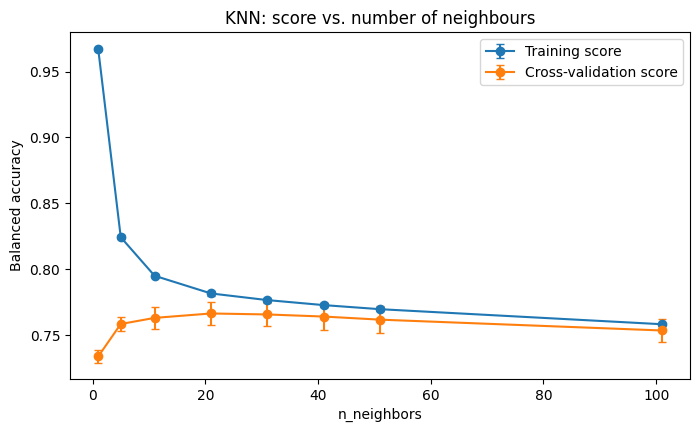

In [ ]:
knn_results = pd.DataFrame(knn_search.cv_results_)
k = knn_results["param_model__n_neighbors"].astype(int)

plt.figure(figsize=(8, 4.5))
plt.errorbar(k, knn_results["mean_train_score"], yerr=knn_results["std_train_score"],
             marker="o", capsize=3, label="Training score")
plt.errorbar(k, knn_results["mean_test_score"], yerr=knn_results["std_test_score"],
             marker="o", capsize=3, label="Cross-validation score")
plt.xlabel("n_neighbors")
plt.ylabel("Balanced accuracy")
plt.title("KNN: score vs. number of neighbours")
plt.legend()
plt.show()

### 6B: Logistic regression

*This cell tunes logistic regression: it tries 12 combinations of `C` and `class_weight`.*

In [ ]:
lr_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
}

lr_search = GridSearchCV(
    make_pipeline_with(LogisticRegression(max_iter=2000)),
    lr_grid,
    cv=cv,
    scoring=SCORING,
    return_train_score=True,
    n_jobs=1,
)
lr_search.fit(X_train, y_train)

best = lr_search.best_index_
print("Best settings:", lr_search.best_params_)
print(f"CV balanced accuracy: {lr_search.cv_results_['mean_test_score'][best]:.3f} "
      f"± {lr_search.cv_results_['std_test_score'][best]:.3f}")

Best settings: {'model__C': 1, 'model__class_weight': 'balanced'}
CV balanced accuracy: 0.821 ± 0.006


*This cell plots the cross-validation score for every value of `C`, with and without `class_weight="balanced"`.*

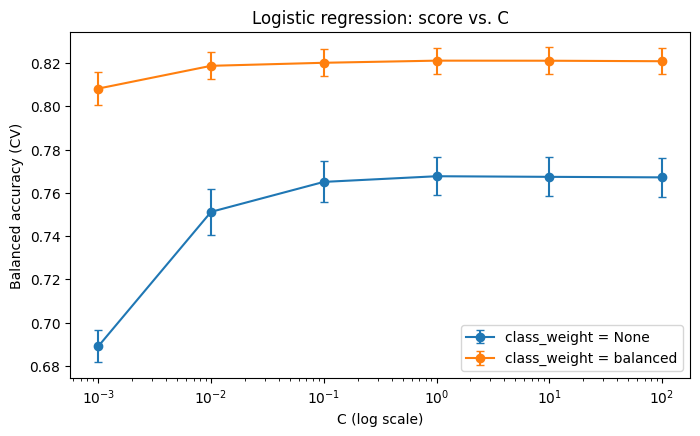

In [ ]:
lr_results = pd.DataFrame(lr_search.cv_results_)

plt.figure(figsize=(8, 4.5))
for weight in [None, "balanced"]:
    subset = lr_results[lr_results["param_model__class_weight"].astype(str) == str(weight)]
    plt.errorbar(subset["param_model__C"].astype(float), subset["mean_test_score"],
                 yerr=subset["std_test_score"], marker="o", capsize=3,
                 label=f"class_weight = {weight}")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Balanced accuracy (CV)")
plt.title("Logistic regression: score vs. C")
plt.legend()
plt.show()

### 6C: Gradient boosting (our own choice)

*This cell tunes gradient boosting: it tries 9 combinations of `learning_rate` and `max_depth`.*

In [ ]:
hgb_grid = {
    "model__learning_rate": [0.03, 0.1, 0.3],
    "model__max_depth": [2, 4, 8],
}

hgb_search = GridSearchCV(
    make_pipeline_with(HistGradientBoostingClassifier(
        max_iter=200,
        early_stopping=False,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
    hgb_grid,
    cv=cv,
    scoring=SCORING,
    return_train_score=True,
    n_jobs=1,
    verbose=1,
)
hgb_search.fit(X_train, y_train)

best = hgb_search.best_index_
print("Best settings:", hgb_search.best_params_)
print(f"CV balanced accuracy: {hgb_search.cv_results_['mean_test_score'][best]:.3f} "
      f"± {hgb_search.cv_results_['std_test_score'][best]:.3f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best settings: {'model__learning_rate': 0.1, 'model__max_depth': 4}
CV balanced accuracy: 0.843 ± 0.008


*This cell plots the training and cross-validation scores for every combination of learning rate and tree depth.*

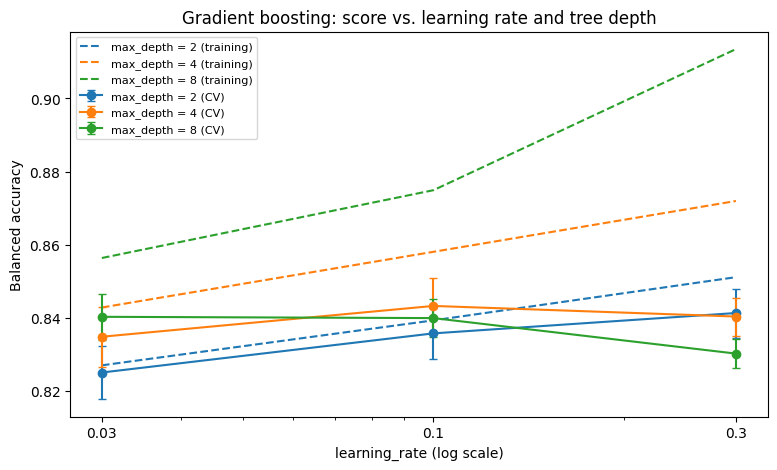

In [ ]:
hgb_results = pd.DataFrame(hgb_search.cv_results_)

plt.figure(figsize=(9, 5))
for depth in [2, 4, 8]:
    subset = hgb_results[hgb_results["param_model__max_depth"].astype(int) == depth]
    lr = subset["param_model__learning_rate"].astype(float)
    line = plt.errorbar(lr, subset["mean_test_score"], yerr=subset["std_test_score"],
                        marker="o", capsize=3, label=f"max_depth = {depth} (CV)")
    plt.plot(lr, subset["mean_train_score"], linestyle="--", color=line[0].get_color(),
             label=f"max_depth = {depth} (training)")
plt.xscale("log")
plt.xticks([0.03, 0.1, 0.3], ["0.03", "0.1", "0.3"])
plt.xlabel("learning_rate (log scale)")
plt.ylabel("Balanced accuracy")
plt.title("Gradient boosting: score vs. learning rate and tree depth")
plt.legend(fontsize=8)
plt.show()

### 6D: Summary of the tuning results

*This cell puts the best result of every model next to the dummy in one table.*

In [ ]:
searches = {
    "KNN": knn_search,
    "Logistic regression": lr_search,
    "Gradient boosting": hgb_search,
}

rows = [{
    "model": "Dummy (baseline)",
    "best hyperparameters": "-",
    "train score": round(dummy_scores["train_score"].mean(), 3),
    "CV mean": round(dummy_scores["test_score"].mean(), 3),
    "CV std": round(dummy_scores["test_score"].std(), 3),
}]

for name, search in searches.items():
    i = search.best_index_
    rows.append({
        "model": name,
        "best hyperparameters": {key.replace("model__", ""): value
                                 for key, value in search.best_params_.items()},
        "train score": round(search.cv_results_["mean_train_score"][i], 3),
        "CV mean": round(search.cv_results_["mean_test_score"][i], 3),
        "CV std": round(search.cv_results_["std_test_score"][i], 3),
    })

summary = pd.DataFrame(rows).set_index("model")
summary

,best hyperparameters,train score,CV mean,CV std
model,,,,
Dummy (baseline),-,0.500,0.500,0.000
KNN,{'n_neighbors': 21},0.782,0.766,0.009
Logistic regression,"{'C': 1, 'class_weight': 'balanced'}",0.822,0.821,0.006
Gradient boosting,"{'learning_rate': 0.1, 'max_depth': 4}",0.858,0.843,0.008


### What we did in step 6
- We tuned three models on the same 5 folds with balanced accuracy.
- KNN scores 0.766, logistic regression 0.821 and gradient boosting 0.843.
- All three models clearly beat both baselines.

#### Details and results

**6A: KNN, what we did**

- KNN predicts the class of a person by looking at the *k* most similar people in the training data (the "neighbours"). We tune `n_neighbors`. With very few neighbours, the model follows random details in the data (**overfitting**). With very many neighbours, the model becomes too simple and misses real patterns (**underfitting**).
- We first tried a rough grid (1, 11, 31, 51, 101). The best score was around 31. Then we tried a finer grid of 8 values: 1, 5, 11, 21, 31, 41, 51 and 101. We only use odd numbers, so the vote between the two classes can never be a tie.
- All values are tested with the same 5 folds and the same metric as the baseline.
- We use `n_jobs=1`, because running the search in parallel got stuck in Colab.

**6A: KNN, what the plot shows**

**What the plot shows:**
- With **1 neighbour**, the training score is 0.967, but the cross-validation score is only 0.734. The model almost remembers the training data, but works much worse on new people. This is clear **overfitting**.
- With more neighbours, the gap between the training score and the cross-validation score gets smaller. The cross-validation score is highest (**0.766**) at 21 to 31 neighbours.
- With **101 neighbours**, both scores go down (0.758 and 0.753). The model becomes too simple: the start of **underfitting**.
- The scores for 21, 31 and 41 neighbours differ less than the spread across the folds (± 0.009). In practice, these values work equally well.
- **Best setting: `n_neighbors` = 21, with a balanced accuracy of 0.766 ± 0.009.**

**6B: Logistic regression, what we did**

- Logistic regression gives every feature a weight (a **coefficient**), adds them up and turns the result into a probability between 0 and 1. Because we can look at the weights, this model is quite easy to **explain**.
- We tune two hyperparameters. This gives 6 × 2 = 12 combinations, each tested on the same 5 folds:
  - `C` controls the **regularisation**. A small `C` limits the model a lot (risk of underfitting). A large `C` gives the model more freedom (risk of overfitting). We try values from 0.001 to 100, each 10 times larger than the one before.
  - `class_weight`: with `None`, every mistake counts the same. With `"balanced"`, mistakes on the smaller group (higher incomes) count more, so the model cannot just ignore that group. This fits our choice of balanced accuracy.
- `max_iter=2000` gives the model enough steps to find the best weights.

**6B: Logistic regression, what the plot shows**

**What the plot shows:**
- **`class_weight="balanced"` makes a big difference:** for every value of `C` it scores about 0.05 higher than `class_weight=None` (0.821 versus 0.768 at `C` = 1). Without balancing, the model leans towards the large group (low income) and misses too many higher incomes.
- **Too much regularisation hurts:** at `C` = 0.001 the model is limited so much that it underfits (0.808 with balancing, 0.689 without).
- **From `C` = 0.1 the score hardly changes** (0.820 to 0.821). These differences are much smaller than the spread across the folds (± 0.006), so these values work equally well.
- **No overfitting:** the training score (0.822) and the cross-validation score (0.821) are almost the same. Logistic regression is a simple model that cannot remember the data like KNN with 1 neighbour can.
- **Best setting: `C` = 1 and `class_weight` = "balanced", with a balanced accuracy of 0.821 ± 0.006.**
- Logistic regression already scores clearly higher than KNN (0.821 versus 0.766).

**6C: Gradient boosting, what we did**

- **Gradient boosting** builds many small decision trees **one after another**. Every new tree tries to fix the mistakes of the trees before it. We use `HistGradientBoostingClassifier`, the fast version in scikit-learn. We chose this model because it often works best on table data like ours, and because it works very differently from KNN (distances) and logistic regression (weights).
- We tune two hyperparameters. This gives 3 × 3 = 9 combinations, each tested on the same 5 folds:
  - `learning_rate`: how big the step of each new tree is. If it is too small, the model does not learn enough in 200 trees (underfitting). If it is too big, the model goes too far (overfitting).
  - `max_depth`: how deep each tree can grow. Shallow trees learn simple patterns. Deep trees can also learn random details of the training data.
- We fixed three settings instead of tuning them:
  - `class_weight="balanced"`, because step 6B showed that balancing clearly improves the balanced accuracy;
  - `max_iter=200` with `early_stopping=False`, so every combination gets exactly the same number of trees. This keeps the comparison fair;
  - `random_state`, so we get the same result every time.

**6C: Gradient boosting, what the plot shows**

**What the plot shows:**
- **Best setting: `learning_rate` = 0.1 and `max_depth` = 4, with a balanced accuracy of 0.843 ± 0.008.** This is the highest score of the three models.
- **Overfitting with deep trees and big steps:** with `max_depth` = 8 and `learning_rate` = 0.3, the training score goes up to 0.914, but the cross-validation score goes down to 0.830. The model learns details that do not work on new data.
- **Underfitting with shallow trees and small steps:** with `max_depth` = 2 and `learning_rate` = 0.03, both scores stay low (0.827 and 0.825). The model is too simple to learn the patterns in 200 trees.
- **Several settings work almost equally well:** the best combinations score between 0.840 and 0.843, which is within the spread across the folds (± 0.008). Avoiding the extremes matters more than the exact choice.

**6D: Summary of the tuning results**

**What the summary shows:**
- **All three models clearly beat both baselines:** the dummy (0.500) and the simple rule `education.num ≤ 10` (0.669 on the training set). Machine learning really adds value here.
- **Gradient boosting scores highest (0.843)**, followed by logistic regression (0.821) and KNN (0.766).
- **Are the differences real?** Gradient boosting scores 0.022 higher than logistic regression. That is about three times the spread across the folds (0.006 to 0.008), so it is probably not chance. The gap between logistic regression and KNN (0.055) is even bigger. We check this in more detail in step 9.
- **Overfitting:** logistic regression has almost no gap between the training score and the CV score (0.822 vs. 0.821). KNN and gradient boosting have a small gap of about 0.015, which is acceptable.
- These are cross-validation scores on the training set. In step 7 we check if they also hold on the test set.

## Step 7: Evaluating on the test set
This is the first and only time we use the test set: 6,508 people that no model has seen before. We do not change any model after this step, because then we would still be using the test set for tuning.

*This cell makes predictions for the test set with every model.*

In [ ]:
dummy.fit(X_train, y_train)

test_predictions = {
    "Dummy (baseline)": dummy.predict(X_test),
    "Simple rule": (X_test["education.num"] <= best_threshold).astype(int).to_numpy(),
    "KNN": knn_search.best_estimator_.predict(X_test),
    "Logistic regression": lr_search.best_estimator_.predict(X_test),
    "Gradient boosting": hgb_search.best_estimator_.predict(X_test),
}

*This cell calculates balanced accuracy, precision, recall and F1 on the test set and adds them to the table from step 6.*

In [ ]:
rows = []
for name, pred in test_predictions.items():
    rows.append({
        "model": name,
        "test balanced accuracy": round(balanced_accuracy_score(y_test, pred), 3),
        "test precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "test recall": round(recall_score(y_test, pred), 3),
        "test F1": round(f1_score(y_test, pred), 3),
    })
test_table = pd.DataFrame(rows).set_index("model")

comparison = summary.copy()
comparison.loc["Simple rule"] = [f"education.num <= {best_threshold}", round(best_score, 3), np.nan, np.nan]
comparison = comparison.join(test_table).loc[list(test_predictions)]
comparison

,best hyperparameters,train score,CV mean,CV std,test balanced accuracy,test precision,test recall,test F1
model,,,,,,,,
Dummy (baseline),-,0.500,0.500,0.000,0.500,0.759,1.000,0.863
Simple rule,education.num <= 10,0.669,NaN,NaN,0.667,0.849,0.761,0.802
KNN,{'n_neighbors': 21},0.782,0.766,0.009,0.773,0.884,0.928,0.906
Logistic regression,"{'C': 1, 'class_weight': 'balanced'}",0.822,0.821,0.006,0.820,0.940,0.803,0.866
Gradient boosting,"{'learning_rate': 0.1, 'max_depth': 4}",0.858,0.843,0.008,0.845,0.951,0.824,0.883


*This cell draws a confusion matrix for every model.*

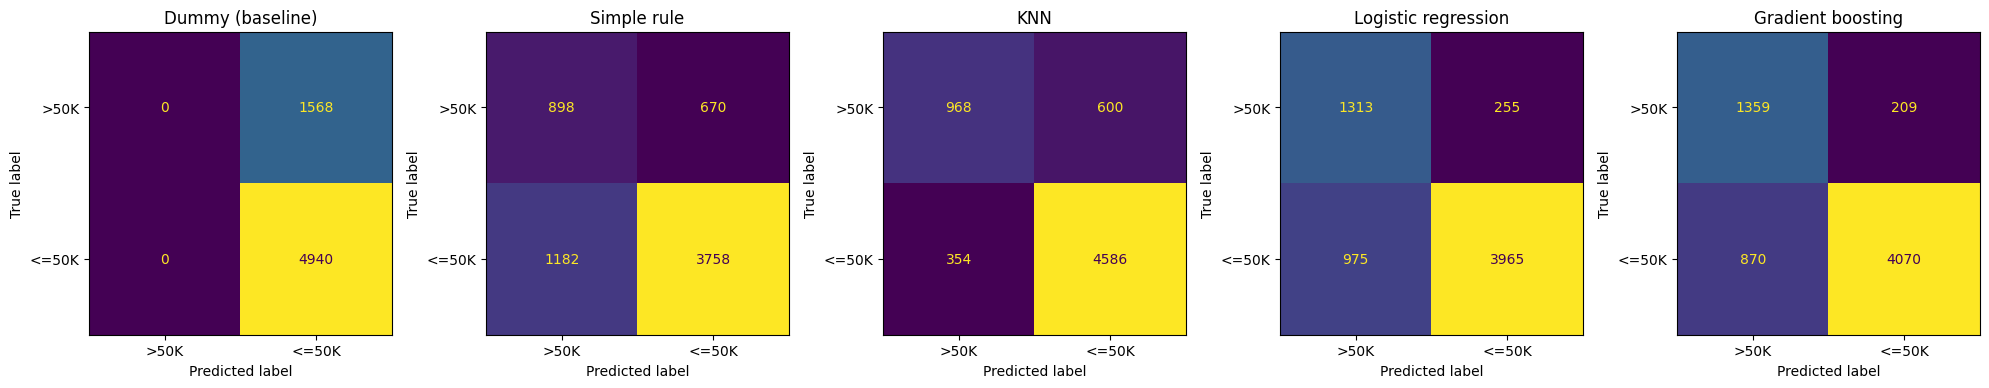

In [ ]:
fig, axes = plt.subplots(1, len(test_predictions), figsize=(4 * len(test_predictions), 4))

for ax, (name, pred) in zip(axes, test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        display_labels=[">50K", "<=50K"],
        ax=ax,
        colorbar=False,
        values_format="d",
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

### What we did in step 7
- We used the test set once, for all models at the same time.
- The test scores are close to the CV scores, and gradient boosting is the best (0.845).
- The models make different mistakes: KNN misses fewer people, but wastes more home visits.

#### Details and results

**What the test results show:**
- **The test scores are very close to the cross-validation scores:** KNN 0.773 (CV 0.766), logistic regression 0.820 (CV 0.821) and gradient boosting 0.845 (CV 0.843). So our cross-validation results were reliable, and no model overfits badly on new data.
- The simple rule has no CV score (NaN), because we chose its threshold on the full training set and not with cross-validation.
- **Gradient boosting scores best on our main metric** (0.845), followed by logistic regression (0.820), KNN (0.773), the simple rule (0.667) and the dummy (0.500).
- **F1 would have been misleading:** the dummy has an F1 of 0.863, almost the same as logistic regression (0.866). This confirms our choice of balanced accuracy in step 1.
- **The models make different mistakes:**
  - **Gradient boosting** misses 870 of the 4,940 low-income people (recall 0.824), but only wrongly targets 209 of the 1,568 people with a higher income.
  - **KNN** misses far fewer low-income people (354, recall 0.928), but wrongly targets 600 people with a higher income. It finds more people who need help, but wastes more home visits.
- **For our user, this is a real trade-off:** every missed person does not get support, but every unnecessary visit costs capacity. In step 9 we look at whether we should lower the decision threshold of the best model, so it misses fewer people.

## Step 8: Looking at the errors
We look at the mistakes of gradient boosting, because it had the highest **cross-validation** score in step 6. We choose on the CV score and not on the test score, because choosing on the test score would mean using the test set to make a decision.

*This cell selects the low-income people the model missed and the ones it found, and compares their averages.*

In [ ]:
best_pred = test_predictions["Gradient boosting"]

errors = X_test.copy()
errors["actual"] = y_test.values
errors["predicted"] = best_pred

missed = errors[(errors["actual"] == 1) & (errors["predicted"] == 0)]
found = errors[(errors["actual"] == 1) & (errors["predicted"] == 1)]
print("Missed low-income people (FN):", len(missed))
print("Found low-income people (TP):", len(found))

pd.DataFrame({
    "Missed (FN)": missed[NUMERIC_FEATURES].mean(),
    "Found (TP)": found[NUMERIC_FEATURES].mean(),
}).round(1)

Missed low-income people (FN): 870
Found low-income people (TP): 4070


,Missed (FN),Found (TP)
age,44.0,34.9
education.num,10.9,9.3
capital.gain,86.3,169.3
capital.loss,51.1,53.9
hours.per.week,44.9,37.2


*This cell compares the marital status of the missed people and the found people.*

In [ ]:
pd.DataFrame({
    "Missed (FN)": missed["marital.status"].value_counts(normalize=True),
    "Found (TP)": found["marital.status"].value_counts(normalize=True),
}).round(2).fillna(0)

,Missed (FN),Found (TP)
marital.status,,
Divorced,0.04,0.18
Married-AF-spouse,0.00,0.00
Married-civ-spouse,0.90,0.21
Married-spouse-absent,0.00,0.02
Never-married,0.04,0.51
Separated,0.01,0.05
Widowed,0.00,0.04


*This cell shows 5 random people that the model missed.*

In [ ]:
missed.sample(5, random_state=RANDOM_STATE)

,age,workclass,education.num,marital.status,occupation,relationship,capital.gain,capital.loss,hours.per.week,native.country,actual,predicted
19778,49,State-gov,10,Married-civ-spouse,Farming-fishing,Husband,0,0,40,United-States,1,0
5423,46,Self-emp-inc,13,Married-civ-spouse,Sales,Husband,0,0,52,United-States,1,0
30886,54,Private,9,Married-civ-spouse,Sales,Husband,0,0,40,United-States,1,0
27609,41,Private,9,Married-civ-spouse,Craft-repair,Husband,0,0,40,Taiwan,1,0
18491,38,Private,9,Married-civ-spouse,Craft-repair,Husband,0,0,41,United-States,1,0


*This cell calculates the scores per sex and per race, to check if the model makes the same mistakes for every group.*

In [ ]:
def group_scores(y_true, y_pred, group):
    rows = []
    for value in group.unique():
        mask = (group == value).to_numpy()
        tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask], labels=[0, 1]).ravel()
        rows.append({
            "group": value,
            "n": int(mask.sum()),
            "share low income": round(y_true[mask].mean(), 3),
            "recall": round(tp / (tp + fn), 3),
            "missed (FNR)": round(fn / (tp + fn), 3),
            "wrongly targeted (FPR)": round(fp / (fp + tn), 3),
            "balanced accuracy": round(balanced_accuracy_score(y_true[mask], y_pred[mask]), 3),
        })
    return pd.DataFrame(rows).set_index("group").sort_values("n", ascending=False)

y_test_array = y_test.to_numpy()
print("By sex:")
display(group_scores(y_test_array, best_pred, groups_test["sex"]))
print("By race:")
display(group_scores(y_test_array, best_pred, groups_test["race"]))

By sex:


,n,share low income,recall,missed (FNR),wrongly targeted (FPR),balanced accuracy
group,,,,,,
Male,4390,0.692,0.761,0.239,0.126,0.817
Female,2118,0.899,0.924,0.076,0.178,0.873


By race:


,n,share low income,recall,missed (FNR),wrongly targeted (FPR),balanced accuracy
group,,,,,,
White,5510,0.740,0.814,0.186,0.128,0.843
Black,642,0.888,0.895,0.105,0.208,0.843
Asian-Pac-Islander,228,0.759,0.792,0.208,0.164,0.814
Amer-Indian-Eskimo,73,0.904,0.848,0.152,0.143,0.853
Other,55,0.927,0.863,0.137,0.250,0.806


### What we did in step 8
- The model mostly misses married, older people who work full-time but still earn little.
- Low-income men are missed three times as often as low-income women.

#### Details and results

**Who does the model miss?**
- Gradient boosting misses 870 of the 4,940 low-income people in the test set.
- **The missed people look like typical high earners.** Compared with the low-income people the model does find, they are older (44 vs. 35 years on average), have more education (`education.num` 10.9 vs. 9.3) and work more hours (45 vs. 37 per week).
- **90% of the missed people are married** (`Married-civ-spouse`), compared with only 21% of the people the model finds. The model has learned that "married, older and working full-time" usually means a higher income. Because of this, it misses married people who still earn little.
- The 5 random examples above confirm this: all five are married men ("Husband") between 38 and 54 years old who work around 40 hours per week, but all of them have a low income.

**Does the model make the same mistakes for everyone?**
- **No. Low-income men are missed three times as often as low-income women:** the model misses 23.9% of low-income men, but only 7.6% of low-income women.
- At the same time, **women with a higher income are more often wrongly targeted** than men with a higher income (17.8% vs. 12.6%).
- This follows the patterns in the data: 90% of the women in the test set have a low income, compared with 69% of the men. `sex` is not a feature, but the model still picks up these differences through proxies such as `relationship` (Husband/Wife) and `marital.status`.
- **For our user, this matters:** a married man with a low income has a much bigger chance of being missed and not getting the support he is entitled to.
- **By race:** the scores for White and Black people are about the same (balanced accuracy 0.843 for both). The other groups are very small in the test set (55 to 228 people), so their scores are not reliable enough to draw conclusions.

## Step 9: Recommendation

*This cell checks if the difference between the models is bigger than the spread across the folds.*

In [ ]:
best_cv = summary.loc["Gradient boosting", "CV mean"]

for name in ["Logistic regression", "KNN"]:
    difference = best_cv - summary.loc[name, "CV mean"]
    spread = max(summary.loc["Gradient boosting", "CV std"], summary.loc[name, "CV std"])
    print(f"Gradient boosting vs. {name}: difference {difference:.3f}, "
          f"largest spread {spread:.3f}, ratio {difference / spread:.1f}x")

Gradient boosting vs. Logistic regression: difference 0.022, largest spread 0.008, ratio 2.8x
Gradient boosting vs. KNN: difference 0.077, largest spread 0.009, ratio 8.6x


*This cell tests five decision thresholds on out-of-fold predictions from the training set.*

In [ ]:
oof_proba = cross_val_predict(
    hgb_search.best_estimator_, X_train, y_train,
    cv=cv,
    method="predict_proba",
)[:, 1]

rows = []
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (oof_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()
    rows.append({
        "threshold": threshold,
        "recall": round(tp / (tp + fn), 3),
        "missed (FN)": fn,
        "wrongly targeted (FP)": fp,
        "wrongly targeted (FPR)": round(fp / (fp + tn), 3),
        "balanced accuracy": round(balanced_accuracy_score(y_train, pred), 3),
    })

pd.DataFrame(rows).set_index("threshold")

,recall,missed (FN),wrongly targeted (FP),wrongly targeted (FPR),balanced accuracy
threshold,,,,,
0.3,0.924,1497,1852,0.295,0.814
0.4,0.870,2567,1261,0.201,0.834
0.5,0.819,3579,830,0.132,0.843
0.6,0.769,4570,565,0.090,0.839
0.7,0.714,5644,373,0.059,0.827


### What we did in step 9
- The difference between gradient boosting and the other models is bigger than the spread across the folds.
- We keep the decision threshold at 0.5 and recommend gradient boosting.

#### Details and results

**Is the difference between the models real?**
- Gradient boosting scores 0.022 higher than logistic regression. This is **2.8 times** the largest spread across the folds (0.008), so the difference is probably not chance.
- Gradient boosting scores 0.077 higher than KNN. This is **8.6 times** the spread, so this difference is clearly real.
- So gradient boosting really is the best model, and not just lucky with the folds.

**Choosing the decision threshold**
- By default, the model predicts "low income" when the probability is 50% or higher. If we lower this threshold, the model misses fewer low-income people, but it also wrongly targets more people with a higher income.
- We tested five thresholds on **out-of-fold predictions from the training set**. Every person got a prediction from a model that had not seen them during training. This way, we did not use the test set for this choice.
- At 0.4, the model would miss about 1,000 fewer low-income people, but it would wrongly target about 430 more people with a higher income. The balanced accuracy would drop from 0.843 to 0.834.
- **We keep the default threshold of 0.5.** It gives the highest balanced accuracy. With a budget of only 500 home visits, every unnecessary visit means that someone else who needs help is not visited. If the budget grows, lowering the threshold to 0.4 is a good way to reach more people.

**Our recommendation**
**We recommend gradient boosting (`learning_rate` = 0.1, `max_depth` = 4) with the default threshold of 0.5.**
- It has the highest balanced accuracy in cross-validation (0.843 ± 0.008) and on the test set (0.845). The difference with the other models is larger than the spread across the folds.
- It clearly beats the simple rule (0.667) and the dummy (0.500), so machine learning adds real value here.
- **Trade-off:** gradient boosting is harder to explain than logistic regression. If the organisation must explain every single decision to the people involved, logistic regression (0.820) is a good alternative that is only a little less accurate.
- **Important limitation (step 8):** the model misses married men with a low income three times as often as women with a low income. The organisation should not rely on the model alone, and should make sure these men have another way to find support.

## Step 10: Using the model

*This cell makes a function that gives a prediction and a probability for one new person.*

In [ ]:
final_model = hgb_search.best_estimator_

def predict_person(person):
    person_df = pd.DataFrame([person])[X_train.columns]
    probability = final_model.predict_proba(person_df)[0, 1]
    prediction = final_model.predict(person_df)[0]
    label = "LOW income (<=50K) → approach" if prediction == 1 else "HIGHER income (>50K) → do not approach"
    print(f"Prediction: {label}")
    print(f"Probability of low income: {probability:.1%}")

*This cell uses the function on two made-up people.*

In [ ]:
person_1 = {
    "age": 29,
    "workclass": "Private",
    "education.num": 9,
    "marital.status": "Never-married",
    "occupation": "Other-service",
    "relationship": "Own-child",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 30,
    "native.country": "United-States",
}
print("Person 1: 29 years old, unmarried, part-time in services")
predict_person(person_1)

print()

person_2 = {
    "age": 47,
    "workclass": "Private",
    "education.num": 9,
    "marital.status": "Married-civ-spouse",
    "occupation": "Craft-repair",
    "relationship": "Husband",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 40,
    "native.country": "United-States",
}
print("Person 2: 47 years old, married man, full-time in craft and repair")
predict_person(person_2)

Person 1: 29 years old, unmarried, part-time in services
Prediction: LOW income (<=50K) → approach
Probability of low income: 99.4%

Person 2: 47 years old, married man, full-time in craft and repair
Prediction: HIGHER income (>50K) → do not approach
Probability of low income: 38.8%


### What we did in step 10
- We made a function that gives a prediction for one new person and tested it on two made-up people.
- Person 2 shows the weak spot of the model from step 8.

#### Details and results

**What the examples show:**
- **Person 1** (29, unmarried, part-time in services) is predicted as low income, with a probability of about 99%. The organisation would contact this person.
- **Person 2** (47, married man, full-time in craft and repair) is predicted as higher income, with only about 39% probability of a low income. The organisation would **not** contact him.
- Person 2 has the same profile as the people the model misses most often (step 8): married, middle-aged men who work full-time. Many of these men do have a low income. This shows that the model should support the decisions of the organisation, not replace them.

## Ethical reflection

**Who is in the data, and who is missing?** The data comes from the US Census of 1994. It only includes people older than 16 who had some income and worked more than 0 hours per week. People without any income or work often need support the most, but they are **not in the data at all**. The data is also unbalanced: 67% of the people are men, 85% are White and 91% were born in the US. Also, $50K in 1994 is worth about double today. **This model should not be used for Dutch or present-day populations** without training it again on recent, local data.

**Does the model make the same mistakes for everyone?** No. `sex` is not a feature, but the model still misses **23.9% of low-income men** and only **7.6% of low-income women** (step 8). Information about sex is still hidden in proxies such as `relationship` (Husband/Wife) and `marital.status`. Removing a sensitive column does not make a model blind to it.

**What does a mistake cost a person?** A missed person (false negative) does not get support they are entitled to, which can lead to debt or financial stress. A wrongly targeted person (false positive) gets an unnecessary visit and may feel labelled as poor.

**Consent and privacy.** The people in the census did not agree that their answers would be used to train a model that decides who gets contacted. We also assume that the organisation has access to tax data (`capital.gain`, `capital.loss`). In real life, this needs a legal basis and careful handling of sensitive financial data.

**What we did about these risks:**
- We did **not** use `sex` and `race` as features, but kept them apart to check the model's mistakes per group.
- We chose **balanced accuracy** and `class_weight="balanced"`, so the model cannot just ignore the smaller group.
- We did a **group check** and found that married men with a low income are missed most often. We report this openly and advise the organisation to give this group another way to find support.
- We advise that the model **supports** the decisions of the organisation, and does not replace human judgement.